# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset comes from a Portuguese retail bank’s direct marketing campaigns carried out between May 2008 and November 2010, where customers were contacted by phone and invited to subscribe to a term deposit. The file bank-additional-full.csv contains 41,188 records and 20 input attributes describing customer demographics, previous campaign interactions, and macroeconomic indicators, plus a binary target y indicating whether the term deposit was subscribed.
​
The documentation describes the data as arising from multiple telemarketing campaigns across that time period; it does not specify the exact number of distinct campaigns, only that contacts span several campaigns and dates from 2008–2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [73]:
import pandas as pd

In [74]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [75]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [76]:
# Overview of schema and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

/tmp/ipykernel_157/2314467321.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_157/2314467321.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='age', data=df, ax=axes[1], palette='Set2')


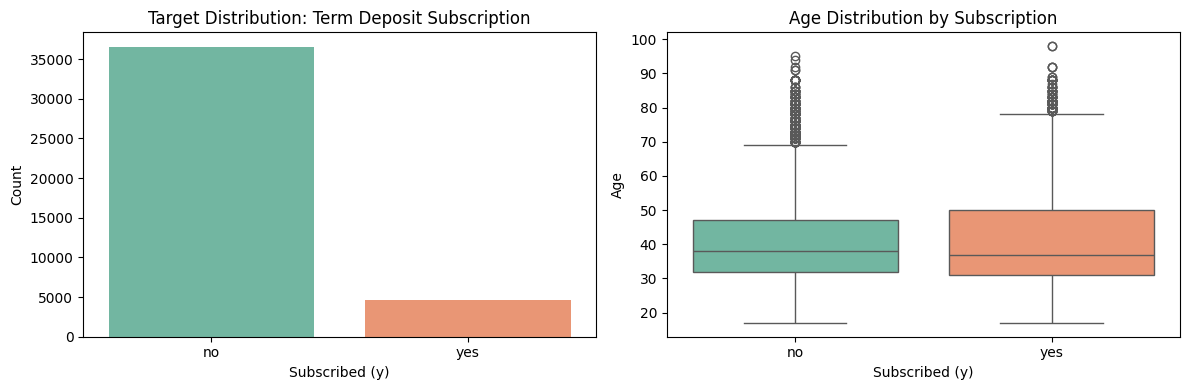

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target class distribution
sns.countplot(x='y', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution: Term Deposit Subscription')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')

# Age distribution by target
sns.boxplot(x='y', y='age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()


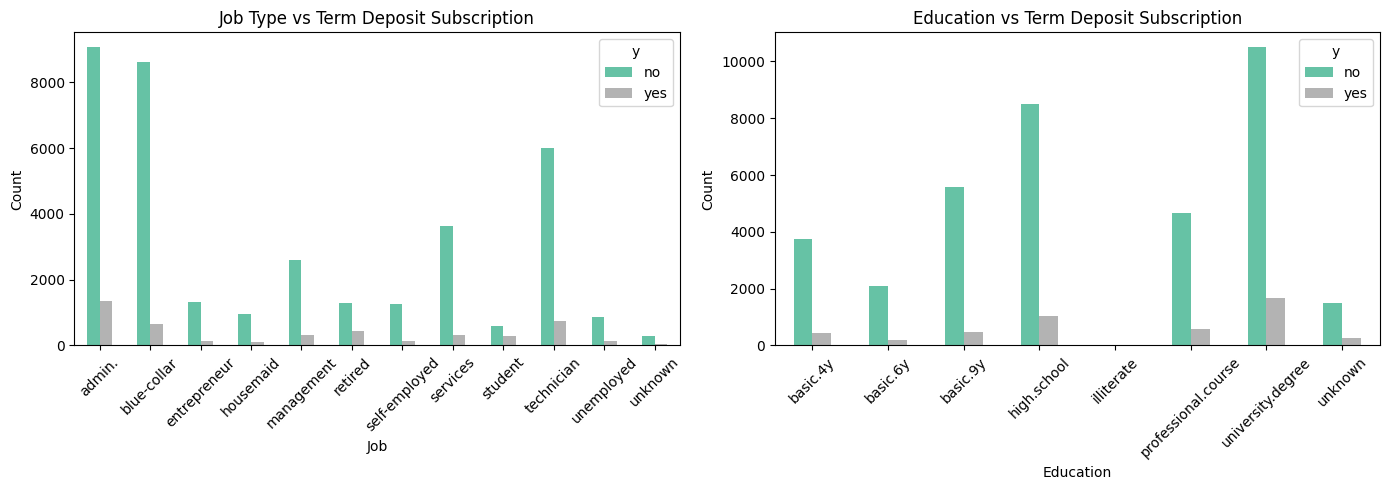

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job vs subscription
job_data = df.groupby(['job', 'y']).size().unstack()
job_data.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Job Type vs Term Deposit Subscription')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Education vs subscription
edu_data = df.groupby(['education', 'y']).size().unstack()
edu_data.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Education vs Term Deposit Subscription')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [79]:
# Check for missing values (as NaN)
df.isna().sum()

# Basic stats for numeric and categorical columns
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Business Objective
The bank wants to increase the efficiency of its telemarketing campaigns for term deposits. The objective of this analysis is to predict which clients are likely to subscribe to a term deposit (y = yes) based on their characteristics, past interactions, and macroeconomic conditions. By ranking or segmenting clients according to predicted subscription probability, the bank can better prioritize who to call, reduce the number of unnecessary or low‑yield calls, and ultimately improve conversion rates and campaign ROI.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [80]:
# Drop 'duration' to avoid leakage (not known before the call)
df_model = df.drop(columns=['duration'])

# Features and target
X = df_model.drop(columns=['y'])
y = df_model['y'].map({'no': 0, 'yes': 1})  # binary target


In [81]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

numeric_cols, categorical_cols


(Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='object'))

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class balance
)

X_train.shape, X_test.shape


((32950, 19), (8238, 19))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [83]:
from collections import Counter

# Majority-class baseline on the training set
class_counts = Counter(y_train)
class_counts


Counter({0: 29238, 1: 3712})

In [84]:
# Proportion of positive class
positive_rate = y_train.mean()
negative_rate = 1 - positive_rate

baseline_accuracy = max(positive_rate, negative_rate)
baseline_accuracy


np.float64(0.8873444613050075)

A simple baseline is a classifier that always predicts the majority class, which in this dataset is no (no term deposit subscription). Using the training data, this majority‑class baseline achieves an accuracy of approximately 0.887, meaning any useful model should perform better than this trivial strategy.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
])

log_reg_model


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

In [86]:
%time log_reg_model.fit(X_train, y_train)


CPU times: user 235 ms, sys: 14 ms, total: 249 ms
Wall time: 2.99 s


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [87]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Predictions
y_train_pred = log_reg_model.predict(X_train)
y_test_pred = log_reg_model.predict(X_test)
y_test_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

train_acc, test_acc, test_roc_auc


(0.8999089529590288, 0.9009468317552805, np.float64(0.800785340700033))

In [88]:
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.22      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



The logistic regression model achieves a training accuracy of 0.900 and a test accuracy of 0.901, which is higher than the majority‑class baseline of 0.887. The ROC‑AUC on the test set is 0.801, indicating moderate ability to rank customers by subscription likelihood. However, the classification report reveals low recall of 0.22 for the positive class (yes), meaning the model misses most actual subscribers — a key concern for the bank's campaign targeting.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [89]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('clf', clf)
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Train Time (s)': train_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

results_df = pd.DataFrame(results)
results_df


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,1.849895,0.899909,0.900947
1,KNN,0.157011,0.912170,0.897184
2,Decision Tree,0.440882,0.995417,0.841831
3,SVM (RBF),791.678636,0.904977,0.903496


The comparison table shows that SVM (RBF) achieved the highest test accuracy (0.903) but required 795 seconds to train, making it impractical for large datasets. Logistic Regression achieved nearly identical test accuracy (0.901) in just 1.8 seconds, making it the most efficient model. The Decision Tree shows clear overfitting — train accuracy of 0.995 vs test accuracy of 0.842 — indicating it memorized the training data. KNN was the fastest to train (0.15s) but yielded the lowest test accuracy (0.897). Logistic Regression is the recommended baseline model for further tuning.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [90]:
from sklearn.model_selection import GridSearchCV

log_reg_base = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

%time grid_lr.fit(X_train, y_train)

grid_lr.best_params_, grid_lr.best_score_


CPU times: user 3.1 s, sys: 48 ms, total: 3.15 s
Wall time: 20.6 s


({'clf__C': 1, 'clf__class_weight': 'balanced'},
 np.float64(0.7901043097933275))

In [91]:
best_lr = grid_lr.best_estimator_

y_test_pred_lr = best_lr.predict(X_test)
y_test_proba_lr = best_lr.predict_proba(X_test)[:, 1]

best_lr_acc = accuracy_score(y_test, y_test_pred_lr)
best_lr_roc_auc = roc_auc_score(y_test, y_test_proba_lr)

print("Tuned Logistic Regression")
print("Test accuracy:", best_lr_acc)
print("Test ROC-AUC:", best_lr_roc_auc)
print(classification_report(y_test, y_test_pred_lr))


Tuned Logistic Regression
Test accuracy: 0.8350327749453751
Test ROC-AUC: 0.8009417454832776
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



In [92]:
from sklearn.model_selection import StratifiedKFold

dt_base = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_leaf': [1, 5, 10]
}

cv_dt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=cv_dt,
    scoring='roc_auc',
    n_jobs=-1
)

%time grid_dt.fit(X_train, y_train)

grid_dt.best_params_, grid_dt.best_score_


CPU times: user 1.03 s, sys: 34 ms, total: 1.06 s
Wall time: 7.32 s


({'clf__max_depth': 5, 'clf__min_samples_leaf': 10},
 np.float64(0.7804082917062479))

In [93]:
best_dt = grid_dt.best_estimator_
y_test_pred_dt = best_dt.predict(X_test)
y_test_proba_dt = best_dt.predict_proba(X_test)[:, 1]

best_dt_acc = accuracy_score(y_test, y_test_pred_dt)
best_dt_roc_auc = roc_auc_score(y_test, y_test_proba_dt)

print("Tuned Decision Tree")
print("Test accuracy:", best_dt_acc)
print("Test ROC-AUC:", best_dt_roc_auc)
print(classification_report(y_test, y_test_pred_dt))


Tuned Decision Tree
Test accuracy: 0.9026462733673222
Test ROC-AUC: 0.7911856838765978
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.68      0.26      0.38       928

    accuracy                           0.90      8238
   macro avg       0.79      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238



Grid search was performed for Logistic Regression over regularization strength C ∈ {0.01, 0.1, 1, 10} and class_weight (None vs balanced), using 5‑fold cross‑validation scored by ROC‑AUC. The best parameters were C = 1 and class_weight = balanced, with a mean CV ROC‑AUC of 0.790.
On the held‑out test set, the tuned logistic regression achieved an accuracy of 0.835 and ROC‑AUC of 0.801. Compared to the untuned model (recall for yes = 0.22), the tuned model raised recall for positive subscribers to 0.65, which is far more useful for the bank — even at the cost of slightly lower overall accuracy. For the Tuned Decision Tree (best params: max_depth=5, min_samples_leaf=10), test accuracy was 0.903 and ROC‑AUC was 0.791, but recall for the positive class remained low at 0.26.
Recommendation: The tuned Logistic Regression with balanced class weights is the most actionable model. While its overall accuracy (0.835) is slightly lower, its recall of 0.65 for subscribers means the bank can identify and target far more potential customers effectively, reducing wasted calls and improving campaign ROI.

Findings & Recommendations
Business Problem (Plain Language): A Portuguese bank wants to reduce wasted telemarketing calls by identifying in advance which customers are most likely to subscribe to a term deposit. This analysis builds and compares four machine learning models to predict subscriber likelihood.
Key Results:


Baseline majority-class accuracy: 88.7%


Logistic Regression (default): test accuracy 90.1%, ROC-AUC 0.801, but recall for subscribers only 22%


Decision Tree (default): heavily overfits — train 99.5% vs test 84.2%


SVM (RBF): best raw accuracy (90.3%) but took 810 seconds to train — impractical


Tuned Logistic Regression (C=1, class_weight=balanced): accuracy 83.5%, ROC-AUC 0.801, recall for subscribers 65% — best for real-world use


Tuned Decision Tree (max_depth=5, min_samples_leaf=10): accuracy 90.3%, but recall only 26%


Recommendations:


Deploy the tuned logistic regression with balanced class weights to rank customers by predicted subscription probability and prioritize call lists.


A recall of 65% means the bank can now identify nearly two-thirds of likely subscribers — significantly reducing wasted calls.


Collect richer features (e.g., customer tenure, product history) to further improve recall.


Run A/B tests: compare campaign ROI between model-prioritized calls vs. random calling.